In [1]:
# Generelle moduler og funksjonsbeskrivelser brukt i forelesningen
from numpy import sin, cos, pi, exp, angle, abs, unwrap, log10
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from IPython.display import Audio

plt.rcParams["figure.figsize"] = [8.00, 4.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.xmargin"] = 0.0

%matplotlib inline

# Enable importing from modules in top-level directory
from sys import path
if path[0] != '..': path.insert(0, '..')

<img src="figurer/NTNU_logo_vertical.svg" align="left" width="30%">
<br clear="all" />
<br></br>

# Differanseligninger

* **Emne: AIS2102 - Dynamiske system**
* ***dato***: 19. januar 2026
* **Foreleser: Kai Erik Hoff**

# Digitale regulatorer
<br>
<br>
<img src="figurer/topic_overview.png" style="width: 70%; margin-left: 10%" />

# Tema

* Differanseligning for derivasjon
    - Implisitt Euler diskretisering av førsteordens system
* Intro til differanseligningen
    - Generell form
    - Systemkoeffisienter
    - Implementasjon
    - Analyse med Python/Matlab

# Første møte med diskretisering: Eulers Metode for førsteordens system 
<!--
* Gitt et førsteordens LTI-system som er beskrevet med en generell differensialligning:
$$\Large a_0 \cdot \frac{d y(t)}{dt} + a_1 \cdot y(t) = b_0 \cdot u(t)$$
Gitt en ukjent funksjon $y(x)$ som avhenger av variabelen $x$, kan egenskapene til $y$ beksrives med en differensialligning dersom det finnes en funksjon $f(x, y)$ slik at:

$$y´=f(x, y)$$


Den generelle formen for Eulers Metode for å beregne tilnærminger til funksjonen $y(x)$ blir da:
$$y_{n+1} = y_n + h\cdot f(x_n, y_n)$$
der $y_n = y(x_n)$ og $x_n = x_0 + n\cdot h$.
-->

* Gitt et førsteordens LTI-system kan differensialligningen skrives på formen:

$$\Large \frac{dy(t)}{dt} = f(t, y(t))$$

* Eulers metode med skrittlengde $T_s$ gir da følgende metode for å beregne tilnærmet verdi $y[k] \approx y(k \cdot T_s)$:
\begin{align} 
y[k] &\approx y[k-1] + T_s \cdot \dot{y}[k-1] \\ \\
&= y[k-1] + T_s \cdot f(t, y(t))
\end{align}
<!--
\begin{align} 
y[k] &= y[k-1] + T_s \cdot \dot{y}[k-1] \ \ \ \ \ \ \ \ \text{(Eulers metode)} \\ \\
&\Downarrow \left( \dot{y}[k-1] = \frac{1}{a_0} \cdot \left(b_0 \cdot u[k-1] -  a_1 \cdot y[k-1] \right) \right) \\ \\
&= y[k-1] + T_s \cdot \frac{1}{a_0} \cdot \left(b_0 \cdot u[k-1] -  a_1 \cdot y[k-1] \right)
\end{align}-->

## Eksempel:
* Bruk eulers metode til å disretisere følgende differensialligning med tidssteg $T_s = 0.125 \text{s}$:

$$ \Large \dot{y}(t) + 2\cdot y(t) = 2 \cdot u(t)$$

$$
\begin{align}
\dot{y}(t) + 2\cdot y(t) &= 2 \cdot u(t) \\
\dot{y}(t) &= 2\cdot u(t) - 2\cdot y(t) \\ \\
y[k] &\approx y[k-1] + T_s \cdot \left( 2\cdot u[k-1] - 2 y[k-1] \right)  \big|_{T_s = 0.125}\\ 
&= y[k-1] + 0.25 u[k-1] - 0.25 y[k-1] \\
&= 0.75 y[k-1] + 0.25 u[k-1] \\ 
y[k] - 0.75 y[k-1] &= 0.25 u[k-1] 
\end{align}
$$

## Demo av Eulers Metode

Kjør kodecellen nedenfor for å se en interaktiv demo for diskretisering av stegresponsen til systemet  $ \dot{y}(t) + 2\cdot y(t) = 2 \cdot u(t)$.

Output()

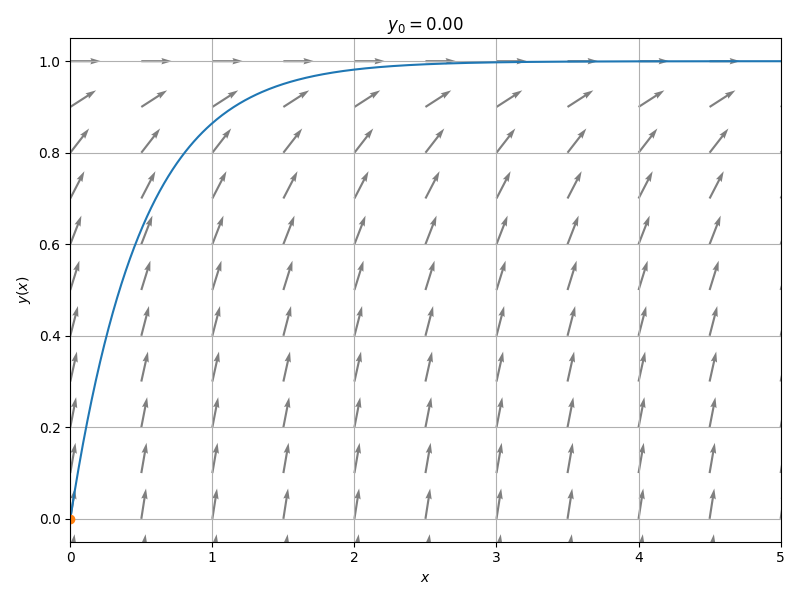

In [38]:
from numerikk_demoer import EulerDemo1D
import numpy as np
%matplotlib ipympl
def f(t, y):
    u = np.heaviside(t, 1) # Enhetssprang
    return 2*u - 2*y

temp = EulerDemo1D(f, y0=0.0, x0=0.0, xN = 5.0, fig_num=1)

# Differanseligningen



* Generell form på alle tidsdisrkete LTI-system (bl.a. digitale regulatorer)
$$
\begin{align}
a_0 \cdot y[k] + a_1 \cdot y[k-1] + \ldots + a_N \cdot y[k-N] &= b_0 \cdot u[k] + b_1 \cdot u[k-1] + \ldots + b_M \cdot u[k-M]\\
\sum_{i=0}^{N} a_i \cdot y[k-i] &= \sum_{i=0}^{M} b_i \cdot u[k-i]
\end{align}
$$
    - Tallrekkene $a_i$ og $b_i$ er systemets *koeffisienter*


* Antar vi at $a_0=1$, kan vi skrive definere følgende **algoritme** for utregning av $y[k]$:
$$y[k] = b_0 \cdot u[k] + b_1 \cdot u[k-1] + \ldots + b_M \cdot u[k-M] -  a_1 \cdot y[k-1] - \ldots - a_N \cdot y[k-N]$$
    * Vi sier at systemet er *normalisert* når $a_0 = 1$

### Sammenligning av stegresponser fra eksempel med Python


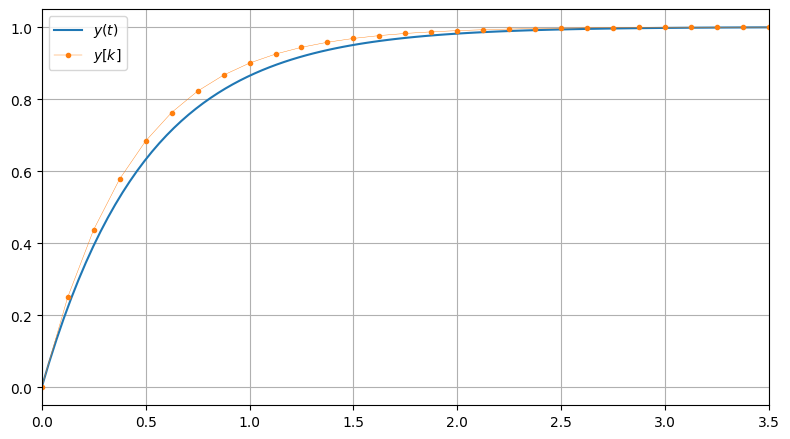

In [40]:
%matplotlib inline

Ts = 0.125
sys_cont = sig.TransferFunction([2], [1, 2]) # Kontinuerlige koeffisienter
sys_disc = sig.TransferFunction([0.25],[1, -.75], dt=Ts) # Tidsdiskrete koeffisienter
t, y = sys_cont.step()
t_k, y_k = sys_disc.step()
y_k = y_k[0].flatten() # Scipy dstep() returnerer en tuple med kolonnevektor 
plt.figure()
plt.plot(t, y, label="$y(t)$")
plt.plot(t_k, y_k, '.-', linewidth=0.3, label="$y[k]$")
plt.xlim(xmax=min(t[-1], t_k[-1]))
plt.legend()
plt.show()

#### I Matlab:


```Octave
Ts = 0.125

sys_disc = tf([2], [10, -8], Ts)
sys_cont = tf([2],[1, 2])

step(sys_cont)
step(sys_disc)

```

# Systemorden

* Antallet tidssteg systemet må huske målinger tilbake i tid

* For en differanseligning
$$\sum_{k=0}^{N} a_k \cdot y[n-k] = \sum_{k=0}^{M} b_k \cdot x[n-k]$$
Systemorden: $\max(N, M)$

* Ved diskretisering: <br>$N$ orden kontinuerlig system $\rightarrow$ $N$ orden diskrét system

# Blokkskjemarepresentasjon

<img src="figurer/df1.svg" style="width: 70%; margin-left: 10%" />

* Hver av blokkene merket $z^{-1}$ representerer én sample forsinkelse, og krever at kodeimplementasjonen inneholder en egen tilstandsvariabel for denne blokken.

# Mulig implementasjon

> ```C++
> class LTI_system {
> private:
>     int order;   // Total system order
>     float b[];   // Feed-forward system Coefficients, length = order + 1
>     float a[];   // Feedback system coefficients, length = order + 1
>     float u_i[]; // Previous Inputs u[k-i], length = order
>     float y_i[]; // Previous Outputs y[k-i], length = order
> 
> public:
>     float process_sample(float u) {
>         float y = b[0] * u;  // Initialize Output y[k]
> 
>         // Add weighted sum of previous inputs/outputs
>         for (int i = 1; i <= order; i++) {  
>             y += b[i] * u_i[i - 1];
>             y -= a[i] * y_i[i - 1];
>         }
> 
>         y /= a[0];  // Divide output by a[0]. May be disregarded if a[0] = 1
> 
>         // Update state vectors
>         for (int i = 1; i < order; i++) {
>             u_i[i] = u_i[i - 1];
>             y_i[i] = y_i[i - 1];
>         }
> 
>         u_i[0] = u;
>         y_i[0] = y;
> 
>         return y;
>     }
> };

```

* *NB! Ufullstendig kode.*

## Regneeksempel
* Beregn så $y[k]$ for sampleintervallet $0 \leq k \leq 6$ gitt differanseligningen $y[k] = 0.25\cdot u[k-1] + 0.75 \cdot y[k-1]$
$$u[k] = \begin{cases}0, & k<0 \\ 1, & k \geq 0 \end{cases}$$
    - Vi kan anta $y[k] = 0$ for $k<0$

#### Løsning:
|$$k$$|$$u[k]$$|$$y[k] = 0.25u[k-1] + 0.75y[k-1]$$|
|---|---|---|
|$$-1$$|$$0$$|$$0$$|
|$$0$$|$$1$$|$$0.25\cdot 0 + 0.75\cdot 0$$|
|$$1$$|$$1$$|$$0.25\cdot 1 + 0.75\cdot 0$$|
|$$2$$|$$1$$|$$0.25\cdot 1 + 0.75\cdot 0.25$$|
|$$3$$|$$1$$|$$0.25\cdot 1 + 0.75\cdot (0.25 + 0.75 \cdot 0.25)$$|
|$$4$$|$$1$$|$$0.25 \cdot (1 + 0.75 + 0.75^2 + 0.75^3)$$|
|$$5$$|$$1$$|$$0.25 \cdot \sum_{i=0}^{4} 0.75^i$$|
|$$6$$|$$1$$|$$0.25 \cdot \frac{1-0.75^6}{1-0.75}$$|
|$$k$$|$$1$$|$$1-0.75^k$$|

### Kodeillustrasjon av regneeksempel:

(0.0, 2.0)

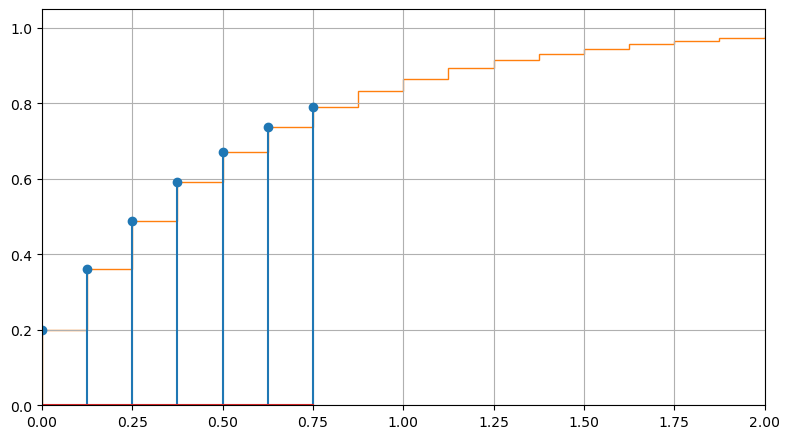

In [4]:

# "Manuell" utregning av stegrespons
y = np.zeros(7)
u = lambda k: (k>=0)*1
for k in range(7):
    y[k] = 0.2*u(k) + 0.8*y[k-1]

# Utregning med dstep()
Ts = 0.125
sys_disc = sig.TransferFunction([2, 0],[10, -8], dt=Ts) # NB!
t_k, y_k = sys_disc.step()
y_k = y_k[0].flatten() # Scipy dstep() returnerer en tuple med kolonnevektor 

# Plotting
plt.stairs(y_k[:-1], t_k, color='C1')
plt.stem(t_k[:7], y)
plt.xlim(xmax=2)

# Enkelt tidsdiskrét lavpassfilter

- Et enkelt og mye brukt førsteordens lavpassfilter:
  $$  y[k] = \alpha \cdot u[k] +(1 - \alpha) \cdot y[k - 1], \quad 0 \leq \alpha < 1  $$
  - Annet navn: «eksponentielt glattefilter»


<img src="figurer/exp_avg.svg" style="width: 40%; margin-left: 10%" />

# Hva med høyereordens LTI-system?



* Eulers metode (og andre metoder) kan benyttes på nesten nøyaktig samme måte, forutsatt at vi omskriver systemet til et sett med førsteordens system (en tilstandsrom-modell)

# Andre Spørsmål?